In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import Dataset
from transformers import (
    AutoImageProcessor,
    ResNetForImageClassification,
    ResNetConfig,
    TrainingArguments,
    Trainer
)

/opt/anaconda3/envs/Dissertation/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-18")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
def generate_dummy_data(num_samples=20):
    data_list = []
    for _ in range(num_samples):
        fake_image = np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
        pil_img = Image.fromarray(fake_image)
        fake_grid_labels = np.random.randint(1, 5, (16, 16))
        data_list.append({
            "image": pil_img,
            "grid_label": fake_grid_labels.tolist()
        })
    return Dataset.from_list(data_list)

In [5]:
raw_dataset = generate_dummy_data(20)

In [6]:
def transform_function(examples):
    inputs = processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")
    batch_labels = []
    for grid in examples["grid_label"]:
        grid_array = np.array(grid)
        one_hot = np.zeros((16, 16, 4), dtype=np.float32)
        for c in range(1, 5):
            one_hot[:, :, c-1] = (grid_array == c).astype(np.float32)
        batch_labels.append(one_hot.flatten())
    inputs["labels"] = torch.tensor(batch_labels)
    return inputs

In [7]:
processed_dataset = raw_dataset.map(transform_function, batched=True, remove_columns=raw_dataset.column_names)
config = ResNetConfig.from_pretrained("microsoft/resnet-18", num_labels=1024)
model = ResNetForImageClassification.from_pretrained(
    "microsoft/resnet-18",
    config=config,
    ignore_mismatched_sizes=True
).to(device)
model.config.problem_type = "multi_label_classification"

Map:   0%|          | 0/20 [00:00<?, ? examples/s]/var/folders/lj/f_7_9gm954v3m19vl9qwk8_c0000gn/T/ipykernel_73298/666933049.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  inputs["labels"] = torch.tensor(batch_labels)
Map: 100%|██████████| 20/20 [00:00<00:00, 119.84 examples/s]
Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-18 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([1024]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 512]) in the checkpoint and torch.Size([1024, 512]) in the model instantiated
You should probably TRAIN this model

In [8]:
training_args = TrainingArguments(
    output_dir="../hf-grid-model",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    logging_steps=1,
    remove_unused_columns=False,
    use_cpu=False if torch.backends.mps.is_available() or torch.cuda.is_available() else True
)

In [9]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_dataset,
)
trainer.train()

/opt/anaconda3/envs/Dissertation/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
1,0.737600
2,0.727500
3,0.724400
4,0.722400
5,0.703500
6,0.697300
7,0.693500
8,0.695000
9,0.685500
10,0.687200


TrainOutput(global_step=15, training_loss=0.6967185695966085, metrics={'train_runtime': 4.697, 'train_samples_per_second': 12.774, 'train_steps_per_second': 3.193, 'total_flos': 634122778705920.0, 'train_loss': 0.6967185695966085, 'epoch': 3.0})

In [10]:
model.eval()

ResNetForImageClassification(
  (resnet): ResNetModel(
    (embedder): ResNetEmbeddings(
      (embedder): ResNetConvLayer(
        (convolution): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU()
      )
      (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (encoder): ResNetEncoder(
      (stages): ModuleList(
        (0): ResNetStage(
          (layers): Sequential(
            (0): ResNetBasicLayer(
              (shortcut): Identity()
              (layer): Sequential(
                (0): ResNetConvLayer(
                  (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
                  (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
                  (activation): ReLU()
           

In [11]:
test_raw_img = raw_dataset[0]["image"]
inputs = processor(test_raw_img, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits.squeeze(0).cpu().numpy()
spatial_logits = logits.reshape(16, 16, 4)
grid_predictions = np.argmax(spatial_logits, axis=-1) + 1

/var/folders/lj/f_7_9gm954v3m19vl9qwk8_c0000gn/T/ipykernel_73298/1461742767.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1', 4)


Text(0.5, 1.0, '2. Hugging Face Model Output (16x16 Matrix)')

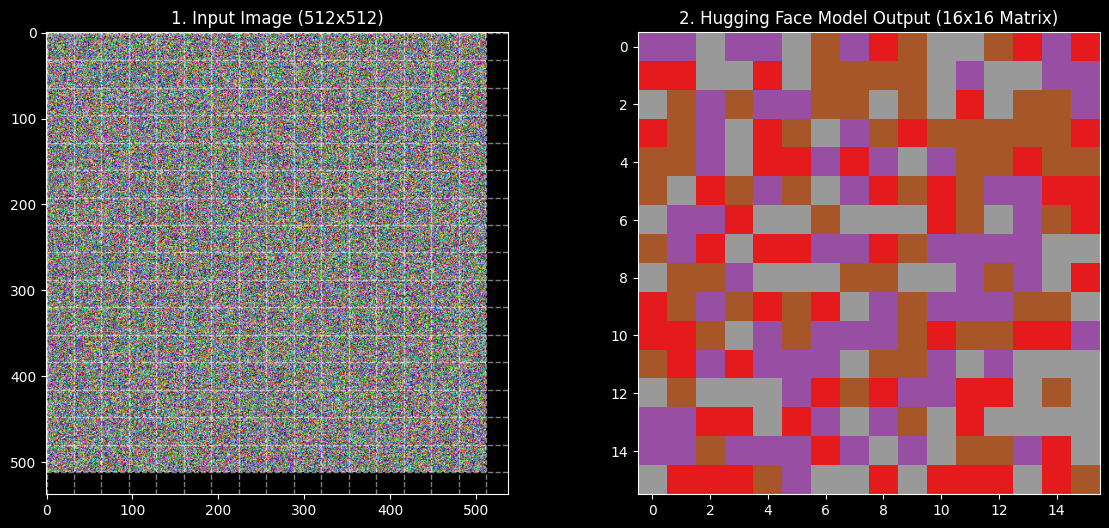

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left
axes[0].imshow(test_raw_img)
axes[0].set_title("1. Input Image (512x512)", fontsize=12)
for x in np.linspace(0, 512, 17):
    axes[0].axvline(x, color='white', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].axhline(x, color='white', linestyle='--', alpha=0.5, linewidth=1)

# right
cmap = plt.cm.get_cmap('Set1', 4)
im = axes[1].imshow(grid_predictions, cmap=cmap, vmin=0.5, vmax=4.5)
axes[1].set_title("2. Hugging Face Model Output (16x16 Matrix)", fontsize=12)

In [13]:
for i in range(16):
    for j in range(16):
        axes[1].text(j, i, str(grid_predictions[i, j]), ha="center", va="center", color="white", fontsize=9)

axes[1].set_xticks(np.arange(16))
axes[1].set_yticks(np.arange(16))
cbar = fig.colorbar(im, ax=axes[1], ticks=[1, 2, 3, 4], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(['Category 1', 'Category 2', 'Category 3', 'Category 4'])

plt.tight_layout()
plt.show()

# 顯示最終產出的二維陣列結果
print("16x16 4 types")
print(grid_predictions)

<Figure size 640x480 with 0 Axes>

16x16 4 types
[[2 2 4 2 2 4 3 2 1 3 4 4 3 1 2 1]
 [1 1 4 4 1 4 3 3 3 3 4 2 4 4 2 2]
 [4 3 2 3 2 2 3 3 4 3 4 1 4 3 3 2]
 [1 3 2 4 1 3 4 2 3 1 3 3 3 3 3 1]
 [3 3 2 4 1 1 2 1 2 4 2 3 3 1 3 3]
 [3 4 1 3 2 3 4 2 1 3 1 3 2 2 1 1]
 [4 2 2 1 4 4 3 4 4 4 1 3 4 2 3 1]
 [3 2 1 4 1 1 2 2 1 3 2 2 2 2 4 4]
 [4 3 3 2 4 4 4 3 3 4 4 2 3 2 4 1]
 [1 3 2 3 1 3 1 4 2 3 2 2 2 3 3 4]
 [1 1 3 4 2 3 2 2 2 3 1 3 3 1 1 2]
 [3 1 2 1 2 2 2 4 3 3 2 4 2 4 4 4]
 [4 3 4 4 4 2 1 3 1 2 2 1 1 4 3 4]
 [2 2 1 1 4 1 2 4 2 3 4 1 4 4 4 4]
 [2 2 3 2 2 2 1 2 4 2 4 3 3 2 1 4]
 [4 1 1 1 3 2 4 4 1 4 1 1 1 4 1 3]]
